## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
from scipy.stats import chi2_contingency

## Data Overview

In [2]:
df = pd.read_csv("../data/raw/netflix_titles.csv")

In [3]:
df.rename(columns={"release_year":"year", "listed_in":"genre"}, inplace=True)

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   show_id      8807 non-null   str  
 1   type         8807 non-null   str  
 2   title        8807 non-null   str  
 3   director     6173 non-null   str  
 4   cast         7982 non-null   str  
 5   country      7976 non-null   str  
 6   date_added   8797 non-null   str  
 7   year         8807 non-null   int64
 8   rating       8803 non-null   str  
 9   duration     8804 non-null   str  
 10  genre        8807 non-null   str  
 11  description  8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [6]:
df.nunique()

show_id        8807
type              2
title          8807
director       4528
cast           7692
country         748
date_added     1767
year             74
rating           17
duration        220
genre           514
description    8775
dtype: int64

The dataset includes 8,807 Netflix titles across 12 columns, with both Movies and TV Shows represented. It provides the main information needed for this analysis, including content type, release year, rating, duration, genre, country, and date added.

The first inspection suggests that the core analysis columns are in good condition overall. The main missing-value issues appear in `director`, `cast`, and `country`, which means these fields should be handled carefully before using them for deeper analysis.

## Data Cleaning

The first step was to check missing values across the dataset. `director`, `cast`, and `country` had noticeable gaps, but dropping all rows with missing values in these columns would remove too much useful data. For that reason, I filled them with `"Unknown"` instead. For columns with only a few missing entries, such as `date_added`, `rating`, and `duration`, I dropped the affected rows since the data loss was very small.

After handling missing values, I cleaned several columns to prepare them for feature engineering. The `duration` column was converted into a numeric format by removing labels such as `"min"` and `"Seasons"`. I also simplified the `genre` column by removing redundant labels such as `"Movies"` and `"TV Shows"`, then split the remaining genres into lists. Finally, `date_added` was parsed as a datetime column, and a `month` column was extracted for later analysis.

After these cleaning steps, the dataset was reduced from 8,807 to 8,790 rows and was ready for the next stage of analysis.

In [7]:
df.shape

(8807, 12)

In [8]:
df.isna().sum()

show_id           0
type              0
title             0
director       2634
cast            825
country         831
date_added       10
year              0
rating            4
duration          3
genre             0
description       0
dtype: int64

In [9]:
threshold = len(df) * 0.05
print(threshold)

440.35


In [10]:
columns_to_drop = df.columns[(df.isna().sum() <= threshold) & (df.isna().sum() > 0)]
print(columns_to_drop)

Index(['date_added', 'rating', 'duration'], dtype='str')


In [11]:
df.dropna(subset=columns_to_drop, inplace=True)
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

In [12]:
df.isna().sum()

show_id        0
type           0
title          0
director       0
cast           0
country        0
date_added     0
year           0
rating         0
duration       0
genre          0
description    0
dtype: int64

In [13]:
df.shape

(8790, 12)

In [14]:
df["duration"] = df["duration"].str.replace(" min", "", regex=False)
df["duration"] = df["duration"].str.replace(r" Seasons?", "", regex=True).astype("int")

df["genre"] = df["genre"].str.replace(" Movies", "", regex=False)
df["genre"] = df["genre"].str.replace(" TV Shows|TV|'", "", regex=True)
df["genre"] = df["genre"].str.split(", ")

df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"], format="%B %d, %Y", errors="coerce")
df["month_added"] = df["date_added"].dt.month
df["year_added"] = df["date_added"].dt.year

## Exploratory Analysis

In [15]:
netflix_palette = ["#E50914", "#221F1F"]
sns.set_palette(sns.color_palette(netflix_palette))

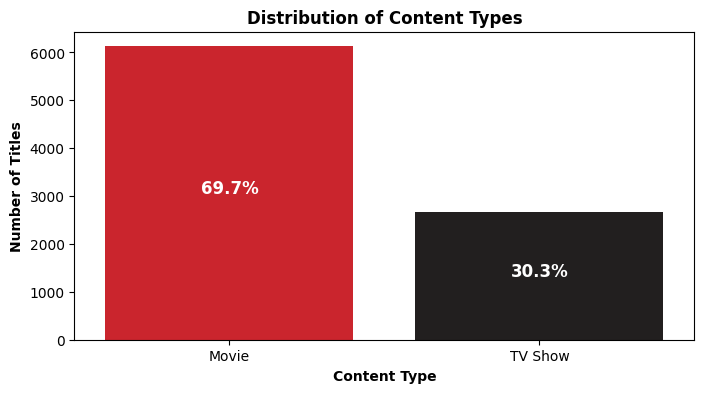

In [16]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="type", hue="type", palette=netflix_palette)
plt.title("Distribution of Content Types", fontsize=12, fontweight="bold")
plt.xlabel("Content Type", fontsize=10, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=10, fontweight="bold")
plt.text(0, 3063, '69.7%', fontsize=12, fontweight="bold", color='white', ha='center')
plt.text(1, 1332, '30.3%', fontsize=12, fontweight="bold", color='white', ha='center')
plt.show()

Movies dominate the Netflix dataset, while TV Shows make up a smaller portion. This imbalance affects comparisons between content types.

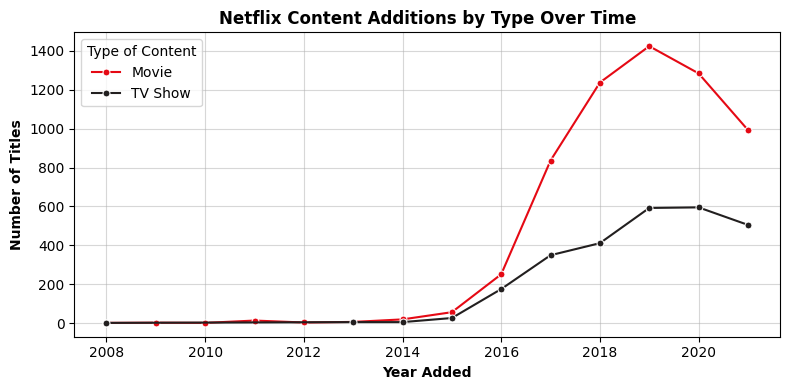

In [17]:
content_release_by_type = df[df["year_added"] >= 2000][["year_added", "type"]].value_counts().sort_index().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=content_release_by_type, x="year_added", y="count", hue="type", palette=netflix_palette, marker="o", markersize=5, errorbar=None)
plt.title("Netflix Content Additions by Type Over Time", fontsize=12, fontweight="bold")
plt.xlabel("Year Added", fontsize=10, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=10, fontweight="bold")
plt.grid(alpha=0.5)
plt.legend().set_title("Type of Content")
plt.tight_layout()
plt.show()

The number of titles added to Netflix increases sharply after 2015. Movies remain higher than TV Shows in most active years.

In [18]:
content_by_year = df[df["year_added"].between(2016, 2021)].groupby(["year_added", "type"])["type"].size().reset_index(name="count")
content_by_year["percentage"] = (content_by_year["count"] / content_by_year.groupby("year_added")["count"].transform("sum") * 100).round(1)

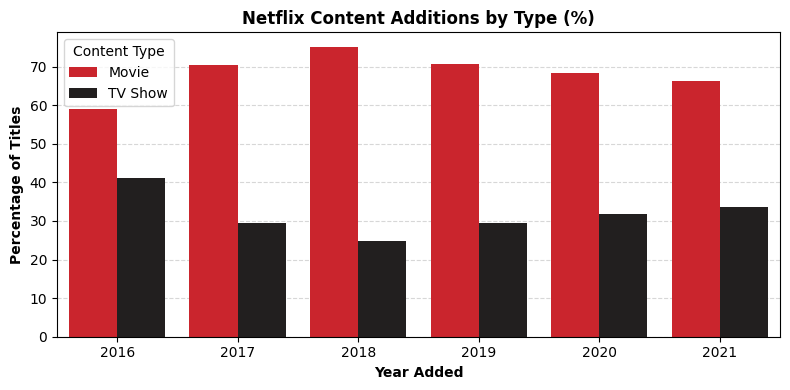

In [19]:
plt.figure(figsize=(8, 4))
sns.barplot(data=content_by_year, x="year_added", y="percentage", hue="type", palette=netflix_palette, zorder=2)

plt.title("Netflix Content Additions by Type (%)", fontsize=12, fontweight="bold")
plt.xlabel("Year Added", fontsize=10, fontweight="bold")
plt.ylabel("Percentage of Titles", fontsize=10, fontweight="bold")
plt.legend(title="Content Type")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Movies make up the majority of titles added in every year from 2016 to 2021. After 2018, the gap between Movies and TV Shows becomes smaller.

In [20]:
def rating_group(rating):
    if rating in ["TV-MA", "R", "NC-17"]:
        return "Adult"
    elif rating in ["TV-14", "PG-13"]:
        return "Teen"
    elif rating in ["G", "PG", "TV-G", "TV-PG", "TV-Y", "TV-Y7", "TV-Y7-FV"]:
        return "Kids/Family"
    elif rating in ["NR", "UR"]:
        return "Unrated"
    else:
        return "Unknown"

df["rating_group"] = df["rating"].apply(rating_group)

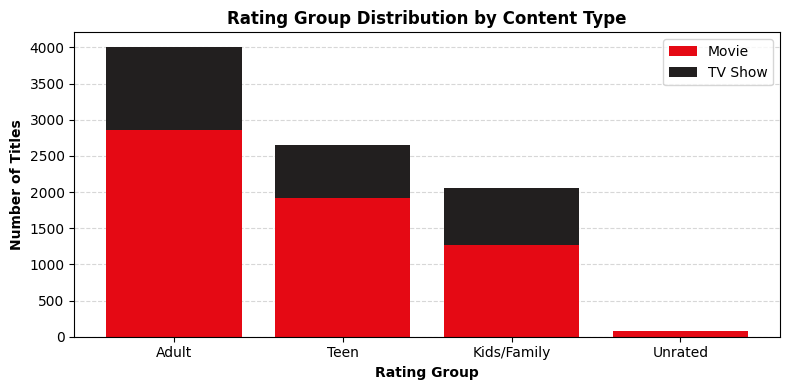

In [21]:
ratings = df.groupby(["rating_group", "type"])["type"].count().unstack(fill_value=0).reset_index().sort_values(by=["Movie", "TV Show"], ascending=[False, False])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x=ratings["rating_group"], height=ratings["Movie"], label="Movie", color="#E50914", zorder=2)
ax.bar(x=ratings["rating_group"], height=ratings["TV Show"], bottom=ratings["Movie"], label="TV Show", color="#221F1F", zorder=2)
plt.title("Rating Group Distribution by Content Type", fontsize=12, fontweight="bold")
plt.xlabel("Rating Group", fontsize=10, fontweight="bold")
plt.ylabel("Number of Titles", fontsize=10, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
plt.legend()
plt.tight_layout()
plt.show()

Adult content is the largest rating group in the dataset, followed by Teen and Kids/Family. Movies make up most titles in each rating group, which is expected because the dataset is movie-heavy overall.

This grouped view makes the rating distribution easier to compare than the raw rating categories.

In [22]:
movies = df[df["type"] == "Movie"].copy()

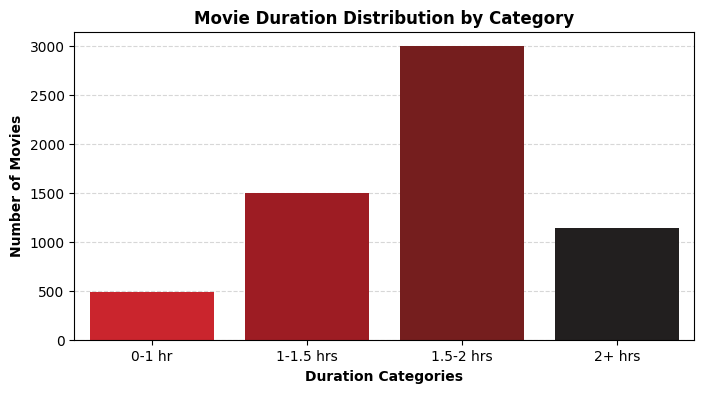

In [23]:
less_than_one_hour = 60
one_to_one_half_hour = 90
one_half_to_two_hour = 120
above_two_hours = movies["duration"].max()

labels = ["0-1 hr", "1-1.5 hrs", "1.5-2 hrs", "2+ hrs"]
bins = [0, less_than_one_hour, one_to_one_half_hour, one_half_to_two_hour, above_two_hours]

movies["duration_category"] = pd.cut(movies["duration"], labels=labels, bins=bins, right=True)
movie_duration_category = movies["duration_category"].value_counts().reset_index()

duration_palette = ["#E50914", "#B20710", "#831010", "#221F1F"]
plt.figure(figsize=(8, 4))
sns.barplot(data=movie_duration_category, x="duration_category", y="count", hue="duration_category", palette=duration_palette, zorder=2, dodge=False, legend=False)
plt.title("Movie Duration Distribution by Category", fontsize=12, fontweight="bold")
plt.xlabel("Duration Categories", fontsize=10, fontweight="bold")
plt.ylabel("Number of Movies", fontsize=10, fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.5, zorder=1)
plt.show()

Most movies are concentrated in the 1.5–2 hour range. Very short movies are much less common, while movies over 2 hours still represent a visible part of the catalog.

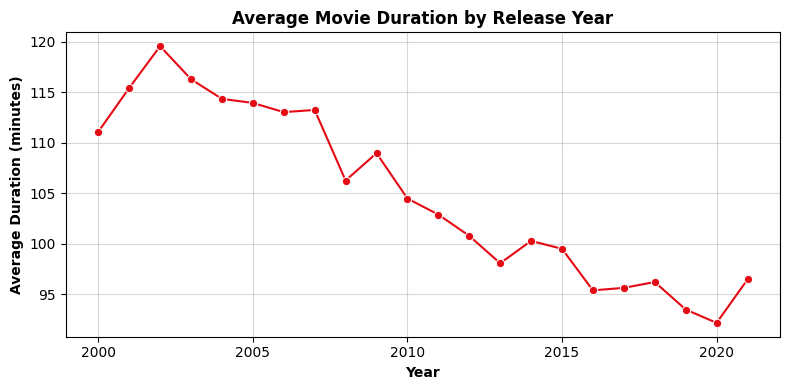

In [24]:
movie_duration_by_year = movies[movies["year"] >= 2000].groupby("year")["duration"].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.lineplot(data=movie_duration_by_year, x="year", y="duration", marker="o", color="#E50914")
plt.title("Average Movie Duration by Release Year", fontsize=12, fontweight="bold")
plt.xlabel("Year", fontsize=10, fontweight="bold")
plt.ylabel("Average Duration (minutes)", fontsize=10, fontweight="bold")
plt.grid(alpha=0.5)
plt.tight_layout()
plt.show()

Average movie duration generally decreases after the early 2000s. This supports the next step of comparing movie duration categories across release eras.

In [25]:
def year_groups(year):
    if year <= 2010:
        return "Before 2010"
    elif year > 2010 and year <= 2015:
        return "2010-2015"
    elif year >= 2016 and year <= 2020:
        return "2016-2020"
    elif year > 2020:
        return "2021+"

movies["era"] = movies["year"].apply(year_groups)

movie_duration_categories_by_year = movies.groupby(["era", "duration_category"]).size().reset_index(name="count")

movie_duration_categories_by_year["percentage"] = (movie_duration_categories_by_year["count"] / 
                                                   movie_duration_categories_by_year.groupby("era")["count"].transform("sum") * 100).round(1)

era_order = ["Before 2010", "2010-2015", "2016-2020", "2021+"]

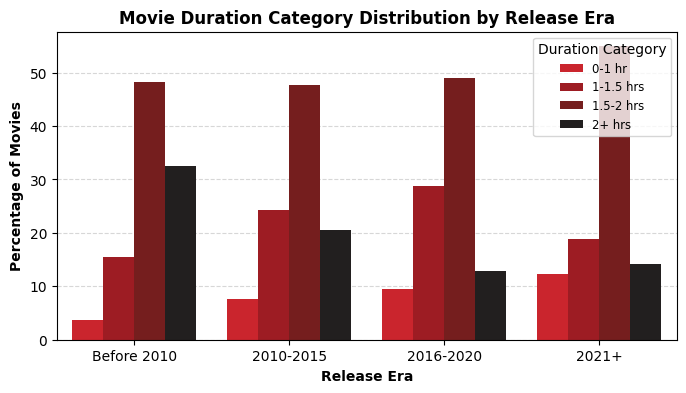

In [26]:
duration_palette = {"0-1 hr": "#E50914", "1-1.5 hrs": "#B20710", "1.5-2 hrs": "#831010", "2+ hrs": "#221F1F"}
plt.figure(figsize=(8, 4))
sns.barplot(data=movie_duration_categories_by_year, x="era", y="percentage", hue="duration_category", palette=duration_palette, order=era_order, zorder=2)
plt.title("Movie Duration Category Distribution by Release Era", fontsize=12, fontweight="bold")
plt.xlabel("Release Era", fontsize=10, fontweight="bold")
plt.ylabel("Percentage of Movies", fontsize=10, fontweight="bold")
plt.legend(title="Duration Category", fontsize="small", loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

The 1.5–2 hour category remains the largest group across all release eras. Movies over 2 hours are more common before 2010, while shorter categories become more visible in later eras.

## Hypothesis Testing

### Test 1: Movie Duration Category and Release Era

This test examines whether movie duration category distribution differs across release eras.

- H₀: Movie duration category distribution is independent of release era.
- H₁: Movie duration category distribution differs across release eras.

A chi-square test of independence is used because both variables are categorical.

First, I created a contingency table to see the observed movie counts for each duration category across release eras. This gives the raw frequency table needed for the chi-square test.

In [27]:
observed_table = pd.crosstab(movies["era"], movies["duration_category"])
observed_table

duration_category,0-1 hr,1-1.5 hrs,1.5-2 hrs,2+ hrs
era,,,,
2010-2015,91,291,574,247
2016-2020,313,958,1638,431
2021+,34,52,152,39
Before 2010,48,202,631,425


Since the total number of movies differs across eras, raw counts alone can be misleading. Therefore, I calculated row-wise percentages to compare the duration distribution within each era more fairly.

In [28]:
duration_era_pct = (pd.crosstab(movies["era"], movies["duration_category"], normalize="index") * 100).round(2)
duration_era_pct

duration_category,0-1 hr,1-1.5 hrs,1.5-2 hrs,2+ hrs
era,,,,
2010-2015,7.56,24.19,47.71,20.53
2016-2020,9.37,28.68,49.04,12.90
2021+,12.27,18.77,54.87,14.08
Before 2010,3.68,15.47,48.32,32.54


The percentage table shows that movies released before 2010 have the highest share of 2+ hour movies, while more recent eras are more concentrated in the 1.5–2 hrs category. This suggests that movie duration distribution may differ across release eras, which is then tested formally using the chi-square test.

The chi-square test compares the observed frequencies with the expected frequencies under the assumption that release era and duration category are independent.

In simple terms, the expected table shows what the distribution would look like if there was no relationship between the two variables. The test then compares these expected values with the observed values from the previous table.

In [29]:
chi2, p_value, dof, expected = chi2_contingency(observed_table)

expected_table = pd.DataFrame(expected, index=observed_table.index, columns=observed_table.columns).round(2)
expected_table

duration_category,0-1 hr,1-1.5 hrs,1.5-2 hrs,2+ hrs
era,,,,
2010-2015,95.44,295.15,588.15,224.26
2016-2020,264.98,819.46,1632.93,622.64
2021+,21.98,67.96,135.43,51.64
Before 2010,103.61,320.42,638.50,243.46


In [30]:
print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 318.5511
p-value: 3.0128e-63
Degrees of freedom: 9


The chi-square test result shows a very small p-value, far below the 0.05 significance level. Therefore, the null hypothesis is rejected.

This suggests that movie duration category distribution is statistically associated with release era.

However, statistical significance does not show how strong the association is. For that reason, I calculated Cramér’s V as an effect size measure.

In [31]:
cramers_v = ss.contingency.association(observed_table, method="cramer")

print(f"Cramér's V: {cramers_v:.4f}")

Cramér's V: 0.1317


The chi-square test indicates a statistically significant association between release era and movie duration category (p < 0.001). However, Cramér’s V is 0.1317, which shows that the strength of this association is small. Cramér’s V ranges from 0 to 1, with lower values indicating a weaker association.

Overall, movie duration patterns are not the same across release eras, but the difference is not very strong. Older movies have a higher share of 2+ hour titles, while movies from newer eras are mostly concentrated in the 1.5–2 hour range. This is an association, not a causal result.

### Test 2: Rating Group and Content Type

This test examines whether rating group distribution differs between Movies and TV Shows.

- H₀: Rating group distribution is independent of content type.
- H₁: Rating group distribution differs between Movies and TV Shows.

A chi-square test of independence is used because both variables are categorical.

First, I created the observed frequency table for content type and rating group. This table shows how many Movies and TV Shows fall into each rating group.

In [32]:
observed_table_2 = pd.crosstab(df["type"], df["rating_group"])
observed_table_2

rating_group,Adult,Kids/Family,Teen,Unrated
type,,,,
Movie,2862,1269,1917,78
TV Show,1145,785,730,4


Because Movies and TV Shows have different total counts, I also used row-wise percentages. This makes the rating group distributions easier to compare within each content type.

In [33]:
rating_type_pct = (pd.crosstab(df["type"], df["rating_group"], normalize="index") * 100).round(2)
rating_type_pct

rating_group,Adult,Kids/Family,Teen,Unrated
type,,,,
Movie,46.72,20.71,31.29,1.27
TV Show,42.98,29.47,27.40,0.15


The percentage table shows visible differences between Movies and TV Shows. TV Shows have a higher share of Kids/Family content, while Movies have slightly higher shares in the Adult and Teen groups. 

The chi-square test is used next to check whether these differences are statistically significant.

As in the first test, I calculated the expected frequencies under the assumption that content type and rating group are independent.

In [34]:
chi2_2, p_value_2, dof_2, expected_2 = chi2_contingency(observed_table_2)

expected_table_2 = pd.DataFrame(expected_2, index=observed_table_2.index, columns=observed_table_2.columns).round(2)
expected_table_2

rating_group,Adult,Kids/Family,Teen,Unrated
type,,,,
Movie,2792.59,1431.49,1844.77,57.15
TV Show,1214.41,622.51,802.23,24.85


In [35]:
print(f"Chi-square statistic: {chi2_2:.4f}")
print(f"p-value: {p_value_2:.4e}")
print(f"Degrees of freedom: {dof_2}")

Chi-square statistic: 100.9865
p-value: 9.5362e-22
Degrees of freedom: 3


The chi-square test result shows a very small p-value, far below the 0.05 significance level. Therefore, the null hypothesis is rejected.

This means that rating group distribution is statistically associated with content type. 

To understand the practical strength of this relationship, I also calculated Cramér’s V.

In [36]:
cramers_v_2 = ss.contingency.association(observed_table_2, method="cramer")

print(f"Cramér's V: {cramers_v_2:.4f}")

Cramér's V: 0.1072


The chi-square test indicates a statistically significant association between content type and rating group (p < 0.001). However, Cramér’s V is 0.1072, which shows that the strength of this association is small.

In short, Movies and TV Shows have different rating distributions, but this difference is small in practice.

### Test 3: Content Type and Year Added

This test examines whether content type distribution differs across years added.

- H₀: Content type distribution is independent of year added.
- H₁: Content type distribution differs across years added.

A chi-square test of independence is used because both variables are treated as categorical. Although `year_added` is numeric, I treat it as a categorical variable in this test because the goal is to compare the Movie/TV Show distribution across individual years.

I filtered the data to 2016–2021, where Netflix additions are more concentrated. Then I created the observed frequency table to compare Movies and TV Shows across years added.

In [37]:
df_filtered = df[df["year_added"].between(2016, 2021)].copy()

observed_table_3 = pd.crosstab(df_filtered["year_added"], df_filtered["type"])
observed_table_3

type,Movie,TV Show
year_added,,
2016,251,175
2017,836,349
2018,1237,411
2019,1424,592
2020,1284,595
2021,993,505


Since the total number of added titles changes by year, I also calculated row-wise percentages. This makes it easier to compare the Movie/TV Show mix within each year.

In [38]:
year_type_pct = (pd.crosstab(df_filtered["year_added"], df_filtered["type"], normalize="index") * 100).round(2)
year_type_pct

type,Movie,TV Show
year_added,,
2016,58.92,41.08
2017,70.55,29.45
2018,75.06,24.94
2019,70.63,29.37
2020,68.33,31.67
2021,66.29,33.71


The percentage table shows that Movies remain the larger share in every year, but the Movie/TV Show mix changes over time. The chi-square test checks whether this change is statistically significant.

In [39]:
chi2_3, p_value_3, dof_3, expected_3 = chi2_contingency(observed_table_3)

expected_table_3 = pd.DataFrame(expected_3, index=observed_table_3.index, columns=observed_table_3.columns).round(2)
expected_table_3

type,Movie,TV Show
year_added,,
2016,296.65,129.35
2017,825.20,359.80
2018,1147.62,500.38
2019,1403.88,612.12
2020,1308.48,570.52
2021,1043.16,454.84


The expected table shows what the Movie/TV Show counts would look like each year if content type and year added were independent.

In [40]:
print(f"Chi-square statistic: {chi2_3:.4f}")
print(f"p-value: {p_value_3:.4e}")
print(f"Degrees of freedom: {dof_3}")

Chi-square statistic: 56.9352
p-value: 5.2149e-11
Degrees of freedom: 5


The p-value is far below 0.05, so the Movie/TV Show mix appears to differ across years added.

In [41]:
cramers_v_3 = ss.contingency.association(observed_table_3, method="cramer")

print(f"Cramér's V: {cramers_v_3:.4f}")

Cramér's V: 0.0811


The chi-square test is statistically significant, but Cramér’s V is 0.0811, indicating a very small relationship in practice.

**Overall**, all three chi-square tests are statistically significant, but the Cramér’s V values are small. This means the differences exist, but they are not strong in practice.

In short, Netflix’s catalog varies across release era, rating group, and year added, but these patterns should not be overstated.